# Pré-processamento — NPS Swift

Notebook separado a partir de `NPS_Swift.ipynb`. Execute este notebook primeiro para gerar `data/base_final.csv` e os parquets usados nas etapas seguintes.


<div style="background:linear-gradient(90deg,#E24307 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:14px 22px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:18px;font-weight:bold;letter-spacing:0.5px;margin:16px 0 6px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);">PARTE 1 — PRÉ-PROCESSAMENTO</div>

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 1. Imports & Configurações</div>

In [ ]:
import os
os.environ.setdefault('MPLCONFIGDIR', os.path.abspath('.matplotlib-cache'))
os.environ.setdefault('XDG_CACHE_HOME', os.path.abspath('.cache'))

import pandas as pd
import numpy as np
import re
import warnings
import unicodedata
from pathlib import Path
try:
    import emoji
except ImportError:
    class _EmojiFallback:
        @staticmethod
        def replace_emoji(text, replace=''):
            return str(text)

        @staticmethod
        def emoji_count(text):
            return 0

    emoji = _EmojiFallback()
    print('[AVISO] Pacote emoji não encontrado; seguindo sem tratamento específico de emojis.')

warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Estatísticas
from scipy import stats

# NLP
import nltk
from nltk.corpus import stopwords

FALLBACK_STOPWORDS_PT = {
    'a', 'à', 'ao', 'aos', 'as', 'às', 'o', 'os', 'um', 'uma', 'uns', 'umas',
    'de', 'da', 'das', 'do', 'dos', 'em', 'na', 'nas', 'no', 'nos', 'por',
    'para', 'com', 'sem', 'sobre', 'entre', 'até', 'após', 'antes', 'desde',
    'e', 'ou', 'mas', 'porém', 'porque', 'que', 'se', 'como', 'quando',
    'onde', 'qual', 'quais', 'quem', 'quanto', 'quantos', 'muito', 'muita',
    'muitos', 'muitas', 'pouco', 'pouca', 'poucos', 'poucas', 'mais', 'menos',
    'já', 'também', 'só', 'não', 'sim', 'foi', 'ser', 'ter', 'tem', 'têm',
    'era', 'são', 'está', 'estão', 'estava', 'estavam', 'me', 'te', 'se',
    'lhe', 'nos', 'vos', 'meu', 'minha', 'meus', 'minhas', 'seu', 'sua',
    'seus', 'suas', 'nosso', 'nossa', 'nossos', 'nossas', 'você', 'vocês',
    'eu', 'tu', 'ele', 'ela', 'eles', 'elas', 'nós', 'isso', 'isto', 'aquilo',
    'este', 'esta', 'esse', 'essa', 'aquele', 'aquela'
}


def get_stopwords_pt():
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        try:
            nltk.download('stopwords', quiet=True)
        except Exception:
            pass

    try:
        return set(stopwords.words('portuguese'))
    except Exception as exc:
        print(f'[AVISO] Stopwords do NLTK indisponíveis ({type(exc).__name__}). Usando lista local reduzida.')
        return FALLBACK_STOPWORDS_PT

# Configurações de exibição
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')

CORES       = {'promotor': '#2ecc71', 'neutro': '#f39c12', 'detrator': '#e74c3c'}
CORES_FLAG  = {'REGULAR': '#3498db', 'TOCADORA': '#9b59b6'}
STOPWORDS_PT = get_stopwords_pt()

# Mapeamento de dias da semana (evita dependência de locale do SO)
DIAS_PT = {0:'Segunda',1:'Terça',2:'Quarta',3:'Quinta',4:'Sexta',5:'Sábado',6:'Domingo'}

# Seed global para reprodutibilidade
import random
random.seed(42)
np.random.seed(42)

# Registro de versões
print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')
print(f'sklearn : ', end='')
import sklearn; print(sklearn.__version__)

Matplotlib is building the font cache; this may take a moment.


pandas  : 3.0.3
numpy   : 2.4.6
sklearn : 1.6.1
[OK] Imports carregados


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 2. Carregamento dos Dados</div>

In [2]:
PATH_AVALIACOES = 'data/dados_nps_swift.xlsx'
PATH_TRANSACOES = 'data/dados_transacoes_lojas.xlsx'

# ── Registro de versão dos dados de entrada (reprodutibilidade) ────────────────
import hashlib
def file_md5(path):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            h.update(chunk)
    return h.hexdigest()

print(f'MD5 avaliações : {file_md5(PATH_AVALIACOES)}')
print(f'MD5 transações : {file_md5(PATH_TRANSACOES)}')

df_aval  = pd.read_excel(PATH_AVALIACOES)
df_trans = pd.read_excel(PATH_TRANSACOES)

print(f'Avaliações : {df_aval.shape[0]:,} linhas | {df_aval.shape[1]} colunas')
print(f'Transações : {df_trans.shape[0]:,} linhas | {df_trans.shape[1]} colunas')

MD5 avaliações : 9b0b0f2728797131ad0bc30cddfc7621
MD5 transações : 56c2de3cb249692022f186f253a19fef
Avaliações : 240,352 linhas | 7 colunas
Transações : 3,645 linhas | 6 colunas


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 3. Inspeção Inicial</div>

In [3]:
print('=== AVALIAÇÕES — Primeiras linhas ===')
display(df_aval.head(5))

print('\n=== AVALIAÇÕES — Info ===')
df_aval.info()

df_aval["Mes Ano"] = df_aval["Mes Ano"].replace("-", np.nan) 
df_aval["classificacao"] = df_aval["classificacao"].replace("-", np.nan) 
df_aval["Data Avaliação"] = df_aval["Data Avaliação"].replace("-", np.nan) 
df_aval["CentroNv2"] = df_aval["CentroNv2"].replace("-", np.nan) 
df_aval["qtd_clientes"] = df_aval["qtd_clientes"].replace("0", np.nan) 
df_aval["Comentario"] = df_aval["Comentario"].replace("-", np.nan)  
df_aval["Flag"] = df_aval["Flag"].replace("-", np.nan) 



print('\n=== AVALIAÇÕES — Nulos e % ===')
nulos = pd.DataFrame({
    'Nulos': df_aval.isnull().sum(),
    '%': (df_aval.isnull().mean() * 100).round(2)
})
display(nulos[nulos['Nulos'] > 0])

print('\n=== AVALIAÇÕES — Estatísticas descritivas ===')
display(df_aval.describe(include='all'))

print('\n=== TRANSAÇÕES — Primeiras linhas ===')
display(df_trans.head(3))
df_trans.info()

=== AVALIAÇÕES — Primeiras linhas ===


,Mes Ano,classificacao,Data Avaliação,CentroNv2,qtd_clientes,Comentario,Flag
0,2025-01-01,promotor,2025-01-01 00:00:00,L5001-RIBEIRAO PRETO (0217),6,-,REGULAR
1,2025-01-01,neutro,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,Bastante falta. De produto. Talvez pela data. Mas não tinha muita coisa. Principalmente bovino,REGULAR
2,2025-01-01,neutro,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,"Estrutura excelente, mas, os peços deveriam ser melhores ou equivalentes aos mercados de carnes",REGULAR
3,2025-01-01,neutro,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,Melhorar o preço!,REGULAR
4,2025-01-01,neutro,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,-,REGULAR



=== AVALIAÇÕES — Info ===
<class 'pandas.DataFrame'>
RangeIndex: 240352 entries, 0 to 240351
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Mes Ano         240352 non-null  datetime64[us]
 1   classificacao   240352 non-null  str           
 2   Data Avaliação  240352 non-null  object        
 3   CentroNv2       240352 non-null  str           
 4   qtd_clientes    240352 non-null  int64         
 5   Comentario      240352 non-null  str           
 6   Flag            239595 non-null  str           
dtypes: datetime64[us](1), int64(1), object(1), str(4)
memory usage: 33.0+ MB

=== AVALIAÇÕES — Nulos e % ===


,Nulos,%
classificacao,454,0.19
Data Avaliação,454,0.19
Comentario,112010,46.60
Flag,757,0.31



=== AVALIAÇÕES — Estatísticas descritivas ===


,Mes Ano,classificacao,Data Avaliação,CentroNv2,qtd_clientes,Comentario,Flag
count,240352,239898,239898,240352,240352.00,128342,239595
unique,NaN,3,503,228,NaN,114608,2
top,NaN,promotor,2025-06-03 00:00:00,L5230-LARGO DO MACHADO,NaN,Mais promoções,REGULAR
freq,NaN,196526,1114,2544,NaN,531,183135
mean,2025-08-28 21:40:41.179603,NaN,NaN,NaN,2.01,NaN,NaN
min,2025-01-01 00:00:00,NaN,NaN,NaN,0.00,NaN,NaN
25%,2025-05-01 00:00:00,NaN,NaN,NaN,1.00,NaN,NaN
50%,2025-09-01 00:00:00,NaN,NaN,NaN,1.00,NaN,NaN
75%,2026-01-01 00:00:00,NaN,NaN,NaN,2.00,NaN,NaN
max,2026-05-01 00:00:00,NaN,NaN,NaN,52.00,NaN,NaN



=== TRANSAÇÕES — Primeiras linhas ===


,CentroNv2,Mes Ano,Regiao_IM,Municipio,UF,Transações
0,L5001-RIBEIRAO PRETO (0217),2025-01-01,Interior,RIBEIRÃO PRETO,SP,9738
1,L5002-ALPHAVILLE (0290),2025-01-01,RMSP,BARUERI,SP,7890
2,L5003-LINS (0340),2025-01-01,Interior,LINS,SP,7111


<class 'pandas.DataFrame'>
RangeIndex: 3645 entries, 0 to 3644
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   CentroNv2   3645 non-null   str           
 1   Mes Ano     3645 non-null   datetime64[us]
 2   Regiao_IM   3645 non-null   str           
 3   Municipio   3645 non-null   str           
 4   UF          3645 non-null   str           
 5   Transações  3645 non-null   int64         
dtypes: datetime64[us](1), int64(1), str(4)
memory usage: 309.7 KB


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 4. Limpeza e Padronização</div>

In [4]:
# ── 4.1 Cópias de trabalho ──────────────────────────────────────────────────
df   = df_aval.copy()
df_t = df_trans.copy()

# ── 4.2 Renomear colunas (snake_case) ────────────────────────────────────────
rename_aval = {
    'Mes Ano'        : 'mes_ano',
    'classificacao'  : 'classificacao',
    'Data Avaliacao' : 'data_avaliacao',
    'Data Avaliação' : 'data_avaliacao',
    'CentroNv2'      : 'centro_nv2',
    'qtd_clientes'   : 'qtd_clientes',
    'Comentario'     : 'comentario',
    'Comentário'     : 'comentario',
    'Flag'           : 'flag',
}
rename_trans = {
    'CentroNv2' : 'centro_nv2',
    'Mes Ano'   : 'mes_ano',
    'Regiao_IM' : 'regiao',
    'Municipio' : 'municipio',
    'UF'        : 'uf',
    'Transacoes': 'transacoes',
    'Transações': 'transacoes',
}

df   = df.rename(columns=rename_aval)
df_t = df_t.rename(columns=rename_trans)

print('Colunas avaliações:', list(df.columns))
print('Colunas transações:', list(df_t.columns))

# ── 4.2b Criar loja_id (código normalizado para joins robustos) ───────────────
# Extrai o padrão L5XXX do centro_nv2 para evitar problemas de encoding (RIBEIRÃO vs RIBEIRAO)
df['loja_id']   = df['centro_nv2'].str.extract(r'(L\d+)', expand=False)
df_t['loja_id'] = df_t['centro_nv2'].str.extract(r'(L\d+)', expand=False)
print(f'loja_id criado — ex: {df["loja_id"].iloc[0]}')

# ── 4.2c Criar avaliacao_id (ID único por registro para rastreabilidade) ─────
df['avaliacao_id'] = range(1, len(df) + 1)
print(f'avaliacao_id criado — range 1..{len(df)}')

Colunas avaliações: ['mes_ano', 'classificacao', 'data_avaliacao', 'centro_nv2', 'qtd_clientes', 'comentario', 'flag']
Colunas transações: ['centro_nv2', 'mes_ano', 'regiao', 'municipio', 'uf', 'transacoes']
loja_id criado — ex: L5001
avaliacao_id criado — range 1..240352


In [5]:
# ── 4.3 Padronizar strings ──────────────────────────────────────────────────

for col in ['classificacao']:
    if col in df.columns:
        df[col] = df[col].str.strip().str.lower()

# Flag padronizada em UPPER (contrato AGENTS.md: REGULAR / TOCADORA)
if 'flag' in df.columns:
    df['flag'] = df['flag'].str.strip().str.upper()

if 'centro_nv2' in df.columns:
    df['centro_nv2'] = df['centro_nv2'].str.strip().str.upper()

df_t['centro_nv2'] = df_t['centro_nv2'].str.strip().str.upper()

df['flag'] = df['flag'].replace('NAN', np.nan)
df['classificacao'] = df['classificacao'].replace('nan', np.nan)

In [6]:
# ── 4.4 Tratar flag inválida (nan) ──────────────────────────────────────────
# 757 registros com flag=nan identificados. Estratégia: remover pois não é
# possível atribuir ao grupo REGULAR ou TOCADORA sem informação.
before = len(df)
flags_validas = {'REGULAR', 'TOCADORA'}
df = df[df['flag'].isin(flags_validas)].copy()
print(f'Removidos por flag inválida: {before - len(df)} registros')
print(f'Shape após filtro de flag  : {df.shape}')

Removidos por flag inválida: 757 registros
Shape após filtro de flag  : (239595, 9)


In [7]:
# ── 4.5 Remover classificação inválida ('-') e qtd_clientes <= 0 ────────────
# Registros com classificação '-' têm qtd_clientes=0: redundante, mas filtramos
# por qtd_clientes para capturar ambos os casos.
before = len(df)
df['qtd_clientes'] = pd.to_numeric(df['qtd_clientes'], errors='coerce')
df = df[df['qtd_clientes'] > 0].dropna(subset=['qtd_clientes']).copy()
print(f'Removidos por qtd_clientes <= 0: {before - len(df)} registros')
print(f'Classificações restantes: {sorted(df["classificacao"].unique())}')

Removidos por qtd_clientes <= 0: 452 registros
Classificações restantes: ['detrator', 'neutro', 'promotor']


In [8]:
# ── 4.6 Tratar transações ────────────────────────────────────────────────────
if df_t['transacoes'].dtype == object:
    df_t['transacoes'] = (
        df_t['transacoes'].astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
    )
df_t['transacoes'] = pd.to_numeric(df_t['transacoes'], errors='coerce')

# ── 4.7 Duplicatas ───────────────────────────────────────────────────────────
# Removemos ANTES de qualquer outra operação para garantir contagens corretas
dup_aval  = df.duplicated().sum()
dup_trans = df_t.duplicated().sum()
print(f'Duplicatas exatas em avaliações : {dup_aval}')
print(f'Duplicatas exatas em transações : {dup_trans}')
df   = df.drop_duplicates().copy()
df_t = df_t.drop_duplicates().copy()

print(f'\nShape avaliações após limpeza: {df.shape}')
print(f'Shape transações após limpeza : {df_t.shape}')
print('[OK] Limpeza concluída')

Duplicatas exatas em avaliações : 0
Duplicatas exatas em transações : 0

Shape avaliações após limpeza: (239143, 9)
Shape transações após limpeza : (3645, 7)
[OK] Limpeza concluída


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 5. Tratamento de Datas</div>

In [9]:
# ── 5.1 data_avaliacao → datetime ────────────────────────────────────────────
df['data_avaliacao'] = pd.to_datetime(df['data_avaliacao'], dayfirst=True, errors='coerce')
print(f'Datas inválidas (NaT): {df["data_avaliacao"].isnull().sum()}')

# ── 5.2 Componentes temporais ─────────────────────────────────────────────────
df['ano']       = df['data_avaliacao'].dt.year
df['mes']       = df['data_avaliacao'].dt.month
df['trimestre'] = df['data_avaliacao'].dt.quarter
df['semana_ano']= df['data_avaliacao'].dt.isocalendar().week.astype('Int64')
df['dia_semana']= df['data_avaliacao'].dt.dayofweek

df['dia_semana_nome'] = df['data_avaliacao'].dt.dayofweek.map(DIAS_PT)

# Period para ordenação correta em gráficos
df['mes_ano_dt'] = df['data_avaliacao'].dt.to_period('M')

# Transações: mes_ano → Period
df_t['mes_ano_dt'] = pd.to_datetime(df_t['mes_ano'], errors='coerce').dt.to_period('M')

# ── 5.3 Sanity check ─────────────────────────────────────────────────────────
df['_check'] = pd.to_datetime(df['mes_ano'], errors='coerce').dt.to_period('M')
inconsistentes = df[df['mes_ano_dt'].notna() & df['_check'].notna() & (df['mes_ano_dt'] != df['_check'])]
print(f'Registros com data fora do mes_ano: {len(inconsistentes)}')
df = df.drop(columns=['_check'])

print('[OK] Datas processadas')
display(df[['data_avaliacao','ano','mes','dia_semana_nome','trimestre','mes_ano_dt']].head(3))

Datas inválidas (NaT): 0
Registros com data fora do mes_ano: 0
[OK] Datas processadas


,data_avaliacao,ano,mes,dia_semana_nome,trimestre,mes_ano_dt
0,2025-01-01,2025,1,Quarta,1,2025-01
1,2025-01-02,2025,1,Quinta,1,2025-01
2,2025-01-02,2025,1,Quinta,1,2025-01


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 6. Tratamento de Texto (Comentários)</div>

In [10]:
# ── 6.1 Identificar comentários ausentes / placeholder ───────────────────────
PLACEHOLDERS = {'-', 'nan', 'none', '', 'n/a', 'nenhum', 'sem comentario',
                'sem comentário', 'nada', 'ok'}

# Guardar texto EXATAMENTE como veio da base (sem nenhum tratamento) para auditoria
df['comentario_original'] = df['comentario']

df['comentario_raw'] = df['comentario'].astype(str).str.strip()
df['tem_comentario'] = ~df['comentario_raw'].str.lower().isin(PLACEHOLDERS)

print(f'COM comentário real : {df["tem_comentario"].sum():,}')
print(f'SEM comentário real : {(~df["tem_comentario"]).sum():,}')
print(f'Taxa de comentários : {df["tem_comentario"].mean()*100:.1f}%')

COM comentário real : 239,135
SEM comentário real : 8
Taxa de comentários : 100.0%


In [11]:
# ── 6.2 Função de limpeza — PRESERVA ACENTOS ───────────────
# Acentos removidos corrompem embeddings BERT/BERTimbau. A limpeza básica
# apenas normaliza espaços, pontuação e números, mantendo texto legível.
def limpar_texto(texto: str) -> str:
    """Limpeza básica para NLP — preserva acentos para compatibilidade com modelos BERT."""
    if not isinstance(texto, str):
        return ''
    texto = texto.lower()
    texto = re.sub(r'[^\w\s]', ' ', texto)   # Remove pontuação, preserva letras acentuadas
    texto = texto.replace('_', ' ')             # \w captura underscore — remover separadamente
    texto = re.sub(r'\b\d+\b', '', texto)     # Remove números isolados
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# Versão sem acento — usada APENAS no CountVectorizer do LDA (não para BERT)
def limpar_texto_sem_acento(texto: str) -> str:
    """Versão sem acentos — usar SOMENTE para LDA/TF-IDF, nunca para transformers."""
    if not isinstance(texto, str):
        return ''
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    return limpar_texto(texto)

df['comentario_limpo'] = df.apply(
    lambda r: limpar_texto(r['comentario_raw']) if r['tem_comentario'] else '',
    axis=1
)

print('[OK] Texto limpo (acentos preservados)')
display(df[df['tem_comentario']][['comentario_raw','comentario_limpo']].head(5))

[OK] Texto limpo (acentos preservados)


,comentario_raw,comentario_limpo
0,NaN,
1,Bastante falta. De produto. Talvez pela data. Mas não tinha muita coisa. Principalmente bovino,bastante falta de produto talvez pela data mas não tinha muita coisa principalmente bovino
2,"Estrutura excelente, mas, os peços deveriam ser melhores ou equivalentes aos mercados de carnes",estrutura excelente mas os peços deveriam ser melhores ou equivalentes aos mercados de carnes
3,Melhorar o preço!,melhorar o preço
4,NaN,


In [12]:
# ── 6.3 Detecção de spam e comentários inválidos ────────────
# Aplicado sobre comentario_limpo (já processado), não sobre raw
# Lógica de emojis: usa lib `emoji` para remoção e detecção

def is_spam(text: str) -> bool:
    text = str(text).strip()
    if len(text) == 0:
        return True
    text_sem_emoji = emoji.replace_emoji(text, replace='').strip()
    if len(text_sem_emoji) == 0:
        return True   # Só emojis = sem informação textual
    alpha = sum(c.isalpha() for c in text_sem_emoji)
    return (
        alpha / len(text_sem_emoji) < 0.40
        or bool(re.match(r'\A(.)\1{4,}\Z', text_sem_emoji))
    )

# Aplicar sobre comentario_limpo (texto já processado)
mask_spam = df['comentario_limpo'].apply(is_spam)
df.loc[mask_spam & df['tem_comentario'], 'tem_comentario'] = False

print(f'Comentários marcados como spam/inválidos: {mask_spam.sum():,}')
print(f'Comentários válidos após filtro          : {df["tem_comentario"].sum():,}')

Comentários marcados como spam/inválidos: 111,234
Comentários válidos após filtro          : 127,909


Média de palavras (com sw)    : 15.9
Média de palavras (sem sw)    : 9.3
Mediana (com sw)              : 9


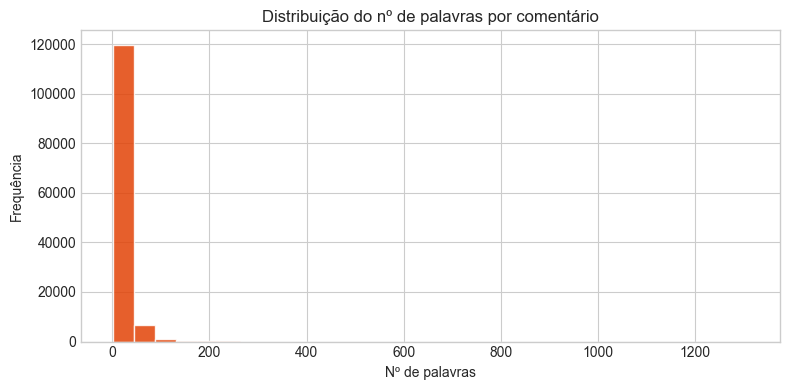

In [13]:
# ── 6.4 Métricas de texto ────────────────────────────────────────────────────
df['qtd_chars']    = df['comentario_limpo'].str.len()
df['qtd_palavras'] = df['comentario_limpo'].str.split().str.len().fillna(0).astype(int)

# ── 6.5 Remover stopwords — coluna separada ───────────────────────────────────
# IMPORTANTE: Modelos transformer (BERTimbau, etc.) devem consumir `comentario_limpo`
# (COM stopwords). A coluna `comentario_sem_sw` é destinada APENAS a abordagens
# bag-of-words (TF-IDF, LDA, CountVectorizer). Transformers dependem do contexto
# gramatical completo para gerar embeddings de qualidade.
def remover_stopwords(texto: str) -> str:
    if not texto:
        return ''
    return ' '.join(w for w in texto.split() if w not in STOPWORDS_PT)

df['comentario_sem_sw'] = df['comentario_limpo'].apply(remover_stopwords)

# Contagem de palavras APÓS remover stopwords — usada no filtro de tópicos
# filtro usa texto pós-stopwords, que reflete o que será entregue ao modelo
df['qtd_palavras_sem_sw'] = df['comentario_sem_sw'].str.split().str.len().fillna(0).astype(int)

comentarios_validos = df[df['tem_comentario']]
print(f'Média de palavras (com sw)    : {comentarios_validos["qtd_palavras"].mean():.1f}')
print(f'Média de palavras (sem sw)    : {comentarios_validos["qtd_palavras_sem_sw"].mean():.1f}')
print(f'Mediana (com sw)              : {comentarios_validos["qtd_palavras"].median():.0f}')

fig, ax = plt.subplots(figsize=(8,4))
ax.hist(comentarios_validos['qtd_palavras'], bins=30, color='#E24307', edgecolor='white', alpha=0.85)
ax.set_title('Distribuição do nº de palavras por comentário')
ax.set_xlabel('Nº de palavras')
ax.set_ylabel('Frequência')
plt.tight_layout()
plt.show()

In [14]:
# ── 6.6 Criar tipo_cliente (schema CLAUDE.md) ────────────────────────────────
TIPO_MAP = {'promotor': 'Promotor', 'neutro': 'Neutro', 'detrator': 'Detrator'}
df['tipo_cliente'] = df['classificacao'].map(TIPO_MAP)

print('tipo_cliente criado:', df['tipo_cliente'].value_counts().to_dict())

tipo_cliente criado: {'Promotor': 195872, 'Neutro': 27963, 'Detrator': 15308}


<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Limitação conhecida — Coluna `classificacao`:</b><br>
A base de entrada fornece apenas a <b>categoria</b> (promotor / neutro / detrator), não a nota numérica original (1–10).<br>
O sistema upstream já aplica a classificação NPS:<br>
• <b>Promotor:</b> notas 9–10<br>
• <b>Neutro:</b> notas 7–8<br>
• <b>Detrator:</b> notas 1–6<br><br>
<b>Impacto:</b> Não é possível realizar análises granulares dentro de cada faixa (ex: separar nota 9 de 10, ou nota 1 de 6). Para o cálculo de NPS e para o pipeline NLP isso não gera nenhuma limitação funcional.
</div>

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 7. Merge das Bases</div>

In [15]:
lojas_aval  = set(df['centro_nv2'].unique())
lojas_trans = set(df_t['centro_nv2'].unique())
print(f'Lojas em avaliações : {len(lojas_aval)}')
print(f'Lojas em transações : {len(lojas_trans)}')
print(f'Lojas em comum      : {len(lojas_aval & lojas_trans)}')
print(f'Só em transações    : {lojas_trans - lojas_aval}')
lojas_sem_transacao = lojas_aval - lojas_trans
print(f'Só em avaliações (sem dados de transação em NENHUM mês): {lojas_sem_transacao if lojas_sem_transacao else "Nenhuma — OK"}')

periodos_aval  = set(df['mes_ano_dt'].dropna().unique())
periodos_trans = set(df_t['mes_ano_dt'].dropna().unique())
sem_cobertura  = periodos_aval - periodos_trans
print(f'\nPeríodos em avaliações : {len(periodos_aval)}')
print(f'Períodos sem transação  : {sem_cobertura}  ← registros terão transacoes=NaN')

df_merge = df.merge(
    df_t[['centro_nv2','mes_ano_dt','transacoes','regiao','municipio','uf']],
    on=['centro_nv2','mes_ano_dt'],
    how='left'
)
cobertura = df_merge['transacoes'].notna().mean() * 100
print(f'\nMerge concluído: {df_merge.shape}')
print(f'Cobertura de transações: {cobertura:.1f}%')

Lojas em avaliações : 227
Lojas em transações : 229
Lojas em comum      : 227
Só em transações    : {'L5293-DIADEMA', 'L5060-RIVIERA (1300)'}
Só em avaliações (sem dados de transação em NENHUM mês): Nenhuma — OK

Períodos em avaliações : 17
Períodos sem transação  : {Period('2026-05', 'M')}  ← registros terão transacoes=NaN

Merge concluído: (239143, 29)
Cobertura de transações: 96.3%


<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Decisão aplicada — Cobertura de transações:</b><br>
O período <code>2026-05</code> (último mês da base) não possui dados de transações na planilha de transações. Todos os registros desse período terão <code>transacoes = NaN</code> após o merge.<br><br>
<b>Estratégia:</b> os registros <b>não são removidos</b> — o NPS é válido independentemente do volume de transações. A coluna <code>transacoes</code> será usada apenas como informação complementar no dashboard. Análises que dependam de <code>transacoes</code> (ex: taxa de resposta) excluirão automaticamente os registros com NaN via <code>dropna()</code> ou <code>notna()</code>.
</div>

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 8. Feature Engineering</div>

In [16]:
# ── 8.1 Score NPS por linha ──────────────────────────────────────────────────
NPS_SCORE_MAP = {'promotor': 100, 'neutro': 0, 'detrator': -100}
df_merge['nps_score']    = df_merge['classificacao'].map(NPS_SCORE_MAP)
df_merge['n_promotores'] = np.where(df_merge['classificacao']=='promotor', df_merge['qtd_clientes'], 0)
df_merge['n_neutros']    = np.where(df_merge['classificacao']=='neutro',   df_merge['qtd_clientes'], 0)
df_merge['n_detratores'] = np.where(df_merge['classificacao']=='detrator', df_merge['qtd_clientes'], 0)
print('[OK] Features NPS criadas')

[OK] Features NPS criadas


In [17]:
# ── 8.2 NPS consolidado por loja × mês ───────────────────────────────────────
nps_loja_mes = (
    df_merge
    .groupby(['centro_nv2','mes_ano_dt','flag','regiao','municipio','uf'])
    .agg(
        total_respostas = ('qtd_clientes',   'sum'),
        n_promotores    = ('n_promotores',   'sum'),
        n_neutros       = ('n_neutros',      'sum'),
        n_detratores    = ('n_detratores',   'sum'),
        transacoes      = ('transacoes',     'first'),
    )
    .reset_index()
)
nps_loja_mes['pct_promotores'] = nps_loja_mes['n_promotores'] / nps_loja_mes['total_respostas'] * 100
nps_loja_mes['pct_detratores'] = nps_loja_mes['n_detratores'] / nps_loja_mes['total_respostas'] * 100
nps_loja_mes['nps']            = nps_loja_mes['pct_promotores'] - nps_loja_mes['pct_detratores']
nps_loja_mes['taxa_resposta_pct'] = (nps_loja_mes['total_respostas'] / nps_loja_mes['transacoes'] * 100).round(2)

print(f'Tabela NPS por loja×mês: {nps_loja_mes.shape}')
display(nps_loja_mes.head(3))

Tabela NPS por loja×mês: (3621, 15)


,centro_nv2,mes_ano_dt,flag,regiao,municipio,uf,total_respostas,n_promotores,n_neutros,n_detratores,transacoes,pct_promotores,pct_detratores,nps,taxa_resposta_pct
0,L5001-RIBEIRAO PRETO (0217),2025-01,REGULAR,Interior,RIBEIRÃO PRETO,SP,243,212,22,9,9738.00,87.24,3.70,83.54,2.50
1,L5001-RIBEIRAO PRETO (0217),2025-02,REGULAR,Interior,RIBEIRÃO PRETO,SP,126,109,11,6,9074.00,86.51,4.76,81.75,1.39
2,L5001-RIBEIRAO PRETO (0217),2025-03,REGULAR,Interior,RIBEIRÃO PRETO,SP,148,135,9,4,9801.00,91.22,2.70,88.51,1.51


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 9. Detecção de Outliers</div>

Outliers IQR    : 37,032 (15.5%)
Outliers Z-Score: 5,180 (2.2%)


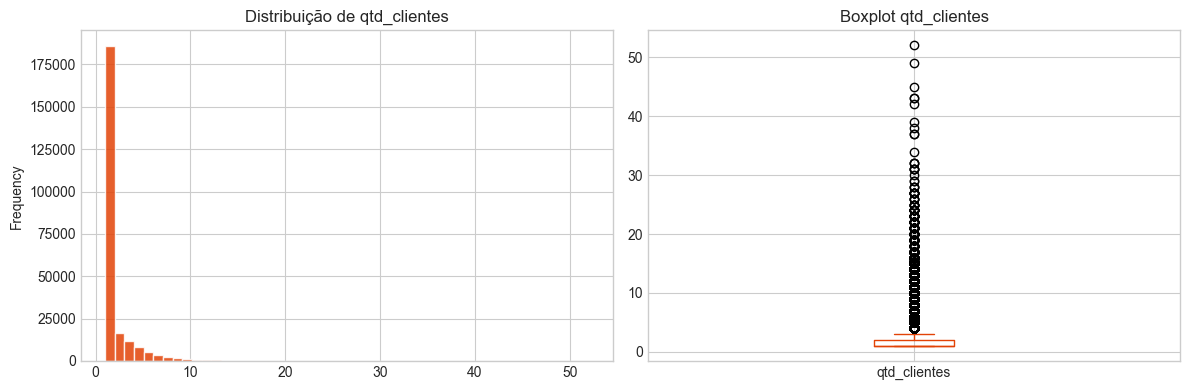

count   239143.00
mean         2.02
std          2.13
min          1.00
25%          1.00
50%          1.00
75%          2.00
95%          6.00
99%         11.00
max         52.00
Name: qtd_clientes, dtype: float64


In [18]:
# ── 9.1 IQR ──────────────────────────────────────────────────────────────────
Q1 = df_merge['qtd_clientes'].quantile(0.25)
Q3 = df_merge['qtd_clientes'].quantile(0.75)
IQR = Q3 - Q1
lim_sup = Q3 + 1.5 * IQR
lim_inf = max(0, Q1 - 1.5 * IQR)

df_merge['outlier_iqr'] = (
    (df_merge['qtd_clientes'] < lim_inf) |
    (df_merge['qtd_clientes'] > lim_sup)
)

# ── 9.2 Z-Score ───────────────────────────────────────────────────────────────
z_scores = np.abs(stats.zscore(df_merge['qtd_clientes'].fillna(0)))
df_merge['outlier_zscore'] = z_scores > 3

# Colunas de outliers
print(f'Outliers IQR    : {df_merge["outlier_iqr"].sum():,} ({df_merge["outlier_iqr"].mean()*100:.1f}%)')
print(f'Outliers Z-Score: {df_merge["outlier_zscore"].sum():,} ({df_merge["outlier_zscore"].mean()*100:.1f}%)')

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(12,4))
df_merge['qtd_clientes'].plot.hist(bins=50, ax=axes[0], color='#E24307', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribuição de qtd_clientes')
df_merge['qtd_clientes'].plot.box(ax=axes[1], color='#E24307')
axes[1].set_title('Boxplot qtd_clientes')
plt.tight_layout(); plt.show()
print(df_merge['qtd_clientes'].describe(percentiles=[.25,.5,.75,.95,.99]))

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 10. Exportação das Bases Tratadas</div>

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Arquivos gerados (contratos do CLAUDE.md):</b><br>
• <code>df_avaliacoes_tratado.parquet</code> — base principal limpa (schema completo)<br>
• <code>df_nps_loja_mes.parquet</code> — NPS agregado por loja × mês<br>
• <code>df_comentarios_nlp.parquet</code> — entrada para todos os módulos NLP<br>
• <code>base_final.csv</code> — backup completo em CSV
</div>

In [19]:
# ── 10.1 df_avaliacoes_tratado — schema completo conforme CLAUDE.md ──────────
colunas_avaliacao = [
    'avaliacao_id', 'mes_ano_dt', 'classificacao', 'tipo_cliente', 'data_avaliacao',
    'centro_nv2', 'loja_id', 'qtd_clientes', 'comentario', 'comentario_original', 'flag',
    'ano', 'mes', 'trimestre', 'semana_ano', 'dia_semana', 'dia_semana_nome',
    'comentario_raw', 'tem_comentario', 'comentario_limpo',
    'comentario_sem_sw', 'qtd_chars', 'qtd_palavras', 'qtd_palavras_sem_sw',
    'nps_score', 'n_promotores', 'n_neutros', 'n_detratores',
    'outlier_iqr', 'outlier_zscore',
    'transacoes', 'regiao', 'municipio', 'uf',
]
# Apenas colunas que existem
colunas_avaliacao = [c for c in colunas_avaliacao if c in df_merge.columns]
df_avaliacoes_tratado = df_merge[colunas_avaliacao].copy()

# Converter Period para string antes de exportar parquet
df_export = df_avaliacoes_tratado.copy()
df_export['mes_ano_dt'] = df_export['mes_ano_dt'].astype(str)

df_export.to_parquet('data/df_avaliacoes_tratado.parquet', index=False)
print(f'[OK] df_avaliacoes_tratado.parquet : {df_export.shape}')

# ── 10.2 df_nps_loja_mes ─────────────────────────────────────────────────────
nps_export = nps_loja_mes.copy()
nps_export['mes_ano_dt'] = nps_export['mes_ano_dt'].astype(str)
nps_export.to_parquet('data/df_nps_loja_mes.parquet', index=False)
print(f'[OK] df_nps_loja_mes.parquet       : {nps_export.shape}')

# ── 10.3 df_comentarios_nlp — entrada para todos os módulos NLP ──────────────
# Schema: centro_nv2, data_avaliacao, flag, tipo_cliente,
#         comentario, comentario_limpo, n_palavras, n_chars
df_comentarios_nlp = df_merge[df_merge['tem_comentario']].copy()
df_comentarios_nlp = df_comentarios_nlp[[
    'centro_nv2', 'data_avaliacao', 'flag', 'tipo_cliente',
    'comentario', 'comentario_limpo', 'qtd_palavras', 'qtd_chars'
]].rename(columns={'qtd_palavras': 'n_palavras', 'qtd_chars': 'n_chars'})

# ── 10.3a Remover duplicatas verdadeiras (texto+loja+dia) ─────────────────────
# São registros que representam o mesmo evento de coleta (ex: qtd_clientes agrupado
# que gerou uma linha duplicada). Manter apenas o primeiro registro.
antes_dup = len(df_comentarios_nlp)
df_comentarios_nlp = df_comentarios_nlp.drop_duplicates(
    subset=['comentario_limpo', 'centro_nv2', 'data_avaliacao'], keep='first'
).copy()
print(f'Duplicatas verdadeiras removidas: {antes_dup - len(df_comentarios_nlp):,}')

# ── 10.3b Filtro mínimo de qualidade textual (n_chars >= 10 E n_palavras >= 2) ─
# Comentários com <= 9 chars (ex: 'ok', 'nota', 'tudo') não carregam informação
# semântica útil para nenhuma tarefa NLP — nem sentimento, nem clusterização.
# Palavras isoladas (ex: 'excelente', 'atendimento') também não têm contexto
# suficiente para embedding ou classificação.
antes_curtos = len(df_comentarios_nlp)
df_comentarios_nlp = df_comentarios_nlp[
    (df_comentarios_nlp['n_chars'] >= 10) &
    (df_comentarios_nlp['n_palavras'] >= 2)
].copy()
print(f'Comentários curtos/1 palavra removidos: {antes_curtos - len(df_comentarios_nlp):,}')

# Remover textos com palavras coladas/lixo de encoding (tokens > 40 chars)
# Ex: 'fazeroprogramadepontosomesinteiroenaosode1a10domes', strings base64
def max_token_len(text):
    words = str(text).split()
    return max((len(w) for w in words), default=0)

mask_lixo = df_comentarios_nlp['comentario_limpo'].apply(max_token_len) > 40
print(f'Comentários com tokens lixo (>40 chars) removidos: {mask_lixo.sum():,}')
df_comentarios_nlp = df_comentarios_nlp[~mask_lixo].copy()

# ── 10.3c Flag comentario_longo (> 350 palavras) ─────────────────────────────
# Modelos transformer têm limite de ~512 tokens (~350 palavras em PT-BR).
# Textos acima disso precisarão de truncagem ou chunking antes de entrar no modelo.
df_comentarios_nlp['comentario_longo'] = df_comentarios_nlp['n_palavras'] > 350
print(f'Comentários longos (>350 palavras): {df_comentarios_nlp["comentario_longo"].sum():,}')

# ── 10.3d Frequência do texto e flag de texto genérico ───────────────────────
# Textos muito repetidos (frases genéricas como 'mais promoções', 'tudo ótimo')
# aparecem em centenas de lojas distintas — são padrões comportamentais reais,
# NÃO devem ser removidos. Mas alimentar 788 cópias idênticas ao modelo distorce
# os clusters. A solução correta é registrar a frequência e deixar a decisão de
# ponderação para a etapa de modelagem.
#
# Uso recomendado na modelagem:
#   - Deduplica pelo texto antes de embeddar
#   - Usa freq_texto como peso no k-means/HDBSCAN
#   - Analisa df_genericos separadamente para insights de frequência
freq_map = df_comentarios_nlp['comentario_limpo'].value_counts()
df_comentarios_nlp['freq_texto'] = df_comentarios_nlp['comentario_limpo'].map(freq_map)
# Threshold: texto que aparece em >= 50 ocorrências é considerado genérico
df_comentarios_nlp['texto_generico'] = df_comentarios_nlp['freq_texto'] >= 50
n_genericos  = df_comentarios_nlp['texto_generico'].sum()
n_uniq_gener = df_comentarios_nlp[df_comentarios_nlp['texto_generico']]['comentario_limpo'].nunique()
print(f'Textos genéricos (freq >= 50): {n_genericos:,} registros | {n_uniq_gener} textos únicos')

# ── 10.3e Documentar viés nos labels de sentimento ───────────────────────────
# ~5% dos Promotores contêm palavras de tom negativo no texto.
# Isso ocorre porque o cliente avalia a experiência geral com nota alta (9-10)
# mas comenta um problema pontual. Se tipo_cliente for usado como ground truth
# para treinar um modelo de sentimento supervisionado, a taxa de ruído nos labels
# é ~5% — aceitável, mas deve ser considerada na avaliação de métricas do modelo.
negativos_pattern = r'ruim|péssimo|pessimo|horrível|horroroso|caro demais|sujo|problema|falta'
promo = df_comentarios_nlp[df_comentarios_nlp['tipo_cliente'] == 'Promotor']
vies = promo['comentario_limpo'].str.contains(negativos_pattern, case=False, na=False).mean()
print(f'Viés de label (Promotores com texto negativo): {vies*100:.1f}%')

nlp_export = df_comentarios_nlp.copy()
nlp_export.to_parquet('data/df_comentarios_nlp.parquet', index=True)
print(f'[OK] df_comentarios_nlp.parquet    : {nlp_export.shape}')

# ── 10.4 base_final.csv — backup completo ────────────────────────────────────
df_merge_backup = df_merge.copy()
df_merge_backup['mes_ano_dt'] = df_merge_backup['mes_ano_dt'].astype(str)
df_merge_backup.to_csv('data/base_final.csv', index=False, sep=';', encoding='utf-8-sig')
print(f'[OK] base_final.csv               : {df_merge_backup.shape}')

[OK] df_avaliacoes_tratado.parquet : (239143, 34)
[OK] df_nps_loja_mes.parquet       : (3621, 15)
Duplicatas verdadeiras removidas: 37
Comentários curtos/1 palavra removidos: 3,167
Comentários com tokens lixo (>40 chars) removidos: 4
Comentários longos (>350 palavras): 16
Textos genéricos (freq >= 50): 6,984 registros | 50 textos únicos
Viés de label (Promotores com texto negativo): 5.1%
[OK] df_comentarios_nlp.parquet    : (124701, 11)
[OK] base_final.csv               : (239143, 35)


In [20]:
# ── 10.5 Divisão NLP: sentimento vs. categorização ───────────────────────────
# Sentimento: usa TODOS os comentários válidos (curtos tb têm valência)
# Categorização (LDA/TF-IDF): exige ≥5 palavras sem stopwords
# Clusterização (embeddings/transformers): exige ≥3 palavras COM stopwords
#   → frases curtas como 'preço alto' ainda carregam informação semântica
# o texto real entregue ao modelo de categorização.
df_nlp      = df_merge[df_merge['tem_comentario']].copy()
df_topicos  = df_nlp[df_nlp['qtd_palavras_sem_sw'] >= 5].reset_index(drop=True)
df_cluster  = df_nlp[df_nlp['qtd_palavras'] >= 3].reset_index(drop=True)

print(f'df_sentimento (todos comentários válidos)       : {len(df_nlp):,}')
print(f'df_topicos    (≥5 palavras sem stopwords, LDA) : {len(df_topicos):,}')
print(f'df_cluster    (≥3 palavras com sw, embeddings) : {len(df_cluster):,}')
print(f'Excluídos da categorização LDA                 : {len(df_nlp)-len(df_topicos):,} comentários curtos')
print(f'Excluídos da clusterização                     : {len(df_nlp)-len(df_cluster):,} comentários curtos')

df_sentimento (todos comentários válidos)       : 127,909
df_topicos    (≥5 palavras sem stopwords, LDA) : 76,360
df_cluster    (≥3 palavras com sw, embeddings) : 116,605
Excluídos da categorização LDA                 : 51,549 comentários curtos
Excluídos da clusterização                     : 11,304 comentários curtos


In [21]:
# ── Relatório final ───────────────────────────────────────────────────────────
print('=' * 60)
print('         RELATÓRIO DE PRÉ-PROCESSAMENTO')
print('=' * 60)
print(f'Registros originais            : {len(df_aval):>10,}')
print(f'Após limpeza (flag + qtd)      : {len(df_merge):>10,}')
print(f'Lojas únicas                   : {df_merge["centro_nv2"].nunique():>10,}')
print(f'Períodos cobertos              : {df_merge["mes_ano_dt"].nunique():>10,}')
print(f'Com comentário real            : {df_merge["tem_comentario"].sum():>10,}')
print(f'NLP — após dedup + filtro chars : {len(nlp_export):>10,}')
print(f'NLP — textos genéricos (freq≥50): {nlp_export["texto_generico"].sum():>10,}')
print(f'NLP — comentários longos (>350w): {nlp_export["comentario_longo"].sum():>10,}')
print(f'Outliers IQR (qtd_clientes)   : {df_merge["outlier_iqr"].sum():>10,}')
print(f'Outliers Z-Score              : {df_merge["outlier_zscore"].sum():>10,}')
print(f'Cobertura de transações        : {df_merge["transacoes"].notna().mean()*100:>9.1f}%')
print()
print('Arquivos exportados:')
print('  data/df_avaliacoes_tratado.parquet')
print('  data/df_nps_loja_mes.parquet')
print('  data/df_comentarios_nlp.parquet')
print('  data/base_final.csv')
print('=' * 60)

         RELATÓRIO DE PRÉ-PROCESSAMENTO
Registros originais            :    240,352
Após limpeza (flag + qtd)      :    239,143
Lojas únicas                   :        227
Períodos cobertos              :         17
Com comentário real            :    127,909
NLP — após dedup + filtro chars :    124,701
NLP — textos genéricos (freq≥50):      6,984
NLP — comentários longos (>350w):         16
Outliers IQR (qtd_clientes)   :     37,032
Outliers Z-Score              :      5,180
Cobertura de transações        :      96.3%

Arquivos exportados:
  data/df_avaliacoes_tratado.parquet
  data/df_nps_loja_mes.parquet
  data/df_comentarios_nlp.parquet
  data/base_final.csv
